# Multilayer Perceptrons, Backpropagation, and Training

This notebook follows the lecture's complete path: inspect real handwritten
digits, implement and train an MLP, derive its gradients from scratch, compare
them with PyTorch automatic differentiation, and run finite-difference and
microbatch-accumulation checks.

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/11-mlp-training/'
for _name in ['SklearnDigits.csv']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 26511
rng = np.random.default_rng(SEED)
digits = pd.read_csv('SklearnDigits.csv')
X = digits.drop(columns='target').to_numpy(float)/16
y = digits.target.to_numpy(int)
print(X.shape, y.shape, np.unique(y))

(1797, 64) (1797,) [0 1 2 3 4 5 6 7 8 9]


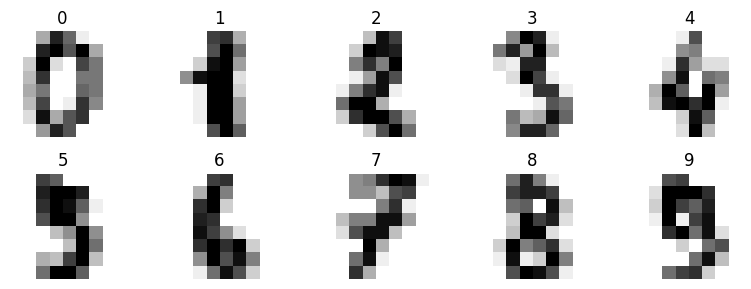

In [2]:
fig, axes = plt.subplots(2,5,figsize=(8,3))
for label, ax in enumerate(axes.ravel()):
    ax.imshow(X[np.flatnonzero(y==label)[0]].reshape(8,8), cmap='gray_r')
    ax.set_title(str(label)); ax.axis('off')
plt.tight_layout();

## A one-hidden-layer network from scratch

In [3]:
order = rng.permutation(len(X))
train, valid = order[:1250], order[1250:]
d, m, K = 64, 32, 10
W1 = rng.normal(0, np.sqrt(2/d), (d,m)); b1 = np.zeros(m)
W2 = rng.normal(0, np.sqrt(2/m), (m,K)); b2 = np.zeros(K)

def forward(Xb):
    A1 = Xb@W1+b1
    H = np.maximum(A1,0)
    logits = H@W2+b2
    shifted = logits-logits.max(1,keepdims=True)
    probability = np.exp(shifted)/np.exp(shifted).sum(1,keepdims=True)
    return A1,H,logits,probability

A1,H,logits,probability = forward(X[train[:5]])
print('X:', X[train[:5]].shape, 'A1:', A1.shape, 'H:', H.shape,
      'logits:', logits.shape, 'probability:', probability.shape)
assert np.allclose(probability.sum(1),1)

X: (5, 64) A1: (5, 32) H: (5, 32) logits: (5, 10) probability: (5, 10)


## Train with the full-batch gradients

In [4]:
learning_rate = .25
history = []
for epoch in range(180):
    A1,H,logits,p = forward(X[train])
    loss = -np.mean(np.log(np.clip(p[np.arange(len(train)),y[train]],1e-12,1)))
    dlogits = p.copy(); dlogits[np.arange(len(train)),y[train]] -= 1; dlogits /= len(train)
    dW2 = H.T@dlogits; db2 = dlogits.sum(0)
    dH = dlogits@W2.T
    dA1 = dH*(A1>0)
    dW1 = X[train].T@dA1; db1 = dA1.sum(0)
    W1 -= learning_rate*dW1; b1 -= learning_rate*db1
    W2 -= learning_rate*dW2; b2 -= learning_rate*db2
    if epoch % 10 == 0:
        train_acc = np.mean(forward(X[train])[-1].argmax(1)==y[train])
        valid_acc = np.mean(forward(X[valid])[-1].argmax(1)==y[valid])
        history.append((epoch,loss,train_acc,valid_acc))
history = pd.DataFrame(history,columns=['epoch','loss','train_accuracy','valid_accuracy'])
history.tail()

,epoch,loss,train_accuracy,valid_accuracy
13,130,0.212465,0.9568,0.946984
14,140,0.200231,0.9592,0.954296
15,150,0.189558,0.9616,0.954296
16,160,0.180145,0.9632,0.956124
17,170,0.171792,0.9640,0.957952


final validation accuracy: 0.9579524680073126


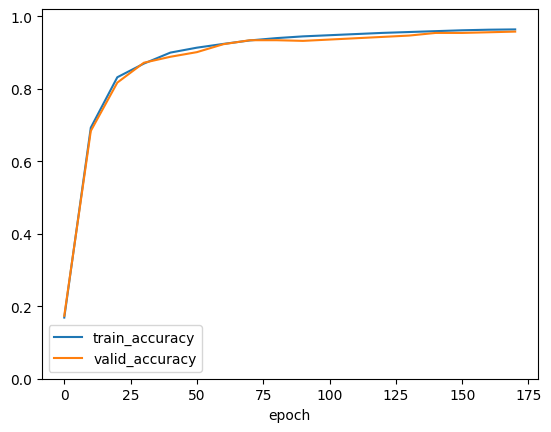

In [5]:
history.plot(x='epoch', y=['train_accuracy','valid_accuracy'], ylim=(0,1.02));
print('final validation accuracy:', history.valid_accuracy.iloc[-1])
assert history.valid_accuracy.iloc[-1] > .90

## PyTorch comparison

In [6]:
import torch
torch.manual_seed(SEED)
model = torch.nn.Sequential(torch.nn.Linear(64,32), torch.nn.ReLU(), torch.nn.Linear(32,10))
X_tensor = torch.tensor(X[train],dtype=torch.float32)
y_tensor = torch.tensor(y[train],dtype=torch.long)
optimizer = torch.optim.SGD(model.parameters(),lr=.25)
for epoch in range(180):
    optimizer.zero_grad()
    loss = torch.nn.functional.cross_entropy(model(X_tensor),y_tensor)
    loss.backward(); optimizer.step()
with torch.no_grad():
    valid_logits = model(torch.tensor(X[valid],dtype=torch.float32))
    valid_accuracy = (valid_logits.argmax(1).numpy()==y[valid]).mean()
print('PyTorch validation accuracy:',valid_accuracy)
print('parameter shapes:',[tuple(p.shape) for p in model.parameters()])
assert valid_accuracy > .90

PyTorch validation accuracy: 0.9341864716636198
parameter shapes: [(32, 64), (32,), (10, 32), (10,)]


# Reverse-Mode Differentiation and Gradient Checks

We now reset the small example and inspect the backward calculation independently
of the optimizer update.

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch

SEED = 26512
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
digits = pd.read_csv('SklearnDigits.csv')
X = digits.drop(columns='target').to_numpy(float)/16
y = digits.target.to_numpy(int)
Xb, yb = X[:32], y[:32]
Xb.shape, yb[:10]

((32, 64), array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

## Forward and backward passes from scratch

In [8]:
n,d,m,K = len(Xb),64,16,10
W1 = rng.normal(0,.12,(d,m)); b1 = rng.normal(0,.02,m)
W2 = rng.normal(0,.12,(m,K)); b2 = rng.normal(0,.02,K)

def forward(W1,b1,W2,b2):
    A1 = Xb@W1+b1
    H = np.tanh(A1)
    logits = H@W2+b2
    shifted = logits-logits.max(1,keepdims=True)
    probability = np.exp(shifted)/np.exp(shifted).sum(1,keepdims=True)
    loss = -np.mean(np.log(probability[np.arange(n),yb]))
    return loss,(A1,H,logits,probability)

loss,cache = forward(W1,b1,W2,b2)
A1,H,logits,p = cache
dlogits = p.copy(); dlogits[np.arange(n),yb] -= 1; dlogits /= n
dW2 = H.T@dlogits; db2 = dlogits.sum(0)
dH = dlogits@W2.T
dA1 = dH*(1-H**2)
dW1 = Xb.T@dA1; db1 = dA1.sum(0)
manual = {'W1':dW1,'b1':db1,'W2':dW2,'b2':db2}
print('loss:',loss)
print({name:value.shape for name,value in manual.items()})

loss: 2.3105499242183685
{'W1': (64, 16), 'b1': (16,), 'W2': (16, 10), 'b2': (10,)}


## PyTorch autograd on identical values

In [9]:
X_t = torch.tensor(Xb,dtype=torch.float64)
y_t = torch.tensor(yb,dtype=torch.long)
parameters = {
    'W1':torch.tensor(W1,requires_grad=True), 'b1':torch.tensor(b1,requires_grad=True),
    'W2':torch.tensor(W2,requires_grad=True), 'b2':torch.tensor(b2,requires_grad=True),
}
torch_logits = torch.tanh(X_t@parameters['W1']+parameters['b1'])@parameters['W2']+parameters['b2']
torch_loss = torch.nn.functional.cross_entropy(torch_logits,y_t)
torch_loss.backward()
for name,value in parameters.items():
    difference = np.max(np.abs(value.grad.numpy()-manual[name]))
    print(name,'maximum difference:',difference)
    assert difference < 1e-12

W1 maximum difference: 1.3877787807814457e-17
b1 maximum difference: 6.938893903907228e-18
W2 maximum difference: 1.3877787807814457e-17
b2 maximum difference: 2.0816681711721685e-17


## Finite differences for selected coordinates

In [10]:
def coordinate_check(name,index,epsilon=1e-5):
    arrays = {'W1':W1.copy(),'b1':b1.copy(),'W2':W2.copy(),'b2':b2.copy()}
    plus = {key:value.copy() for key,value in arrays.items()}
    minus = {key:value.copy() for key,value in arrays.items()}
    plus[name][index] += epsilon; minus[name][index] -= epsilon
    loss_plus = forward(plus['W1'],plus['b1'],plus['W2'],plus['b2'])[0]
    loss_minus = forward(minus['W1'],minus['b1'],minus['W2'],minus['b2'])[0]
    numeric = (loss_plus-loss_minus)/(2*epsilon)
    analytic = manual[name][index]
    return analytic,numeric,abs(analytic-numeric)/max(1,abs(analytic),abs(numeric))

for item in [('W1',(0,0)),('W1',(20,7)),('b1',(3,)),('W2',(4,8)),('b2',(2,))]:
    print(item,coordinate_check(*item))

('W1', (0, 0)) (np.float64(0.0), np.float64(0.0), np.float64(0.0))
('W1', (20, 7)) (np.float64(0.008593367862212872), np.float64(0.008593367839537791), np.float64(2.2675080563194783e-11))
('b1', (3,)) (np.float64(0.0016501412129504593), np.float64(0.0016501412236635813), np.float64(1.0713122012770415e-11))
('W2', (4, 8)) (np.float64(0.00350570319388203), np.float64(0.0035057031944063506), np.float64(5.243206042948589e-13))
('b2', (2,)) (np.float64(0.006488463783429686), np.float64(0.006488463788478781), np.float64(5.049095690157213e-12))


## Correct microbatch accumulation

In [11]:
model = torch.nn.Linear(64,10,bias=False).double()
values = torch.tensor(X[:64],dtype=torch.float64)
labels = torch.tensor(y[:64],dtype=torch.long)
model.zero_grad(); torch.nn.functional.cross_entropy(model(values),labels).backward()
full = model.weight.grad.detach().clone()

model.zero_grad()
for start in range(0,64,16):
    micro_loss = torch.nn.functional.cross_entropy(model(values[start:start+16]),labels[start:start+16])
    (.25*micro_loss).backward()
accumulated = model.weight.grad.detach().clone()
print('relative difference:',torch.norm(accumulated-full).item()/torch.norm(full).item())
assert torch.allclose(accumulated,full,atol=1e-12)

relative difference: 2.2241404921233674e-16


## Part 2 --- every figure in the slides

These cells are the code that produced the figures in the deck, with each file write replaced by an inline plot.

In [12]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The course palette and figure sizes, copied from slides/figures/sds265_style.py
BLUE, BLUE_BRIGHT, RED, GREEN = '#00356B', '#286DC0', '#7A3E47', '#5B7864'
INK, MUTED, RULE, BLUE_PALE = '#202A35', '#66727E', '#D8E0E8', '#F2F6FA'
BLUE_FILL, RED_FILL, GREEN_FILL = '#7B8FA3', '#A3838A', '#8FA394'
CYCLE = [BLUE, RED, GREEN, BLUE_BRIGHT, MUTED]
TEXTWIDTH, TEXTHEIGHT = 5.63, 3.09
FULL, FULL_TALL, FULL_SHORT = (TEXTWIDTH, 2.0), (TEXTWIDTH, 2.35), (TEXTWIDTH, 1.7)
HALF, HALF_TALL = (2.70, 2.05), (2.70, 2.45)

def use_course_style():
    mpl.rcParams.update({'figure.dpi': 130, 'font.size': 9, 'axes.titlecolor': BLUE,
                         'axes.edgecolor': MUTED, 'axes.linewidth': .7,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'xtick.color': MUTED, 'ytick.color': MUTED,
                         'legend.frameon': False, 'lines.linewidth': 1.8,
                         'axes.prop_cycle': mpl.cycler(color=CYCLE)})

def save(fig, *paths):     # the deck writes files; the notebook shows the plot
    plt.show()
    return Path(paths[0]) if paths else Path('figure.pdf')

use_course_style()
# The figure scripts locate the data through OUT.parents[2]; point OUT at the
# directory the deck uses because figure names are derived from it.
COURSE = Path.cwd().parents[1]
OUT = COURSE / 'slides' / 'figures' / '11-mlp-training'
NOTES = COURSE / 'lectures' / 'figures'

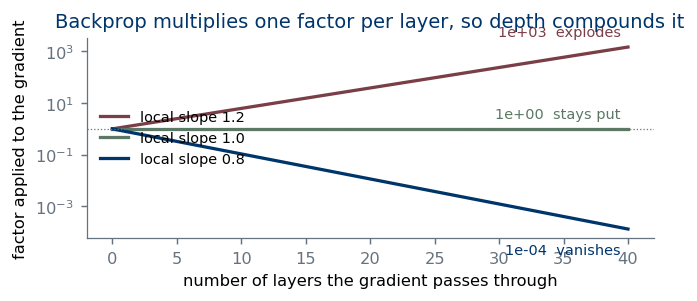

factors at depth 40: {0.8: 0.000133, 1.0: 1.0, 1.2: 1469.771568}


In [13]:
from __future__ import annotations


import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch





def gradient_products() -> None:
    """What repeated multiplication by a local slope does to a gradient."""
    depth = np.arange(0, 41)
    fig, ax = plt.subplots(figsize=FULL)
    for slope, colour, note in ((1.2, RED, "explodes"), (1.0, GREEN, "stays put"), (0.8, BLUE, "vanishes")):
        factor = slope ** depth
        ax.plot(depth, factor, color=colour, label=f"local slope {slope}")
        ax.annotate(f"{factor[-1]:.0e}  {note}", (depth[-1], factor[-1]),
                    textcoords="offset points", xytext=(-4, 6 if slope != 0.8 else -14),
                    ha="right", fontsize=8, color=colour)
    ax.axhline(1, color=MUTED, lw=.7, ls=":")
    ax.set(yscale="log", xlabel="number of layers the gradient passes through",
           ylabel="factor applied to the gradient",
           title="Backprop multiplies one factor per layer, so depth compounds it")
    ax.legend(loc="center left", fontsize=8)
    save(fig, OUT / "gradient-products.pdf", OUT / "gradient-products.svg")
    print("factors at depth 40:", {s: round(float(s ** 40), 6) for s in (0.8, 1.0, 1.2)})

gradient_products()

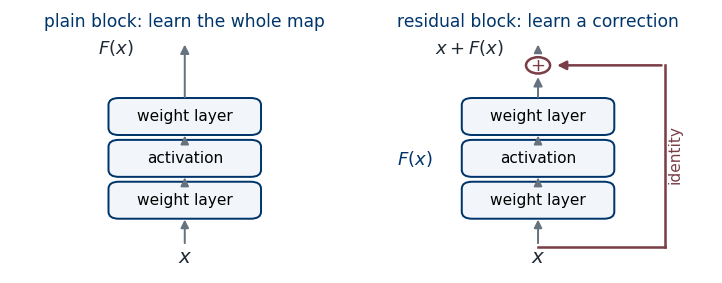

In [14]:
def residual_block() -> None:
    """A plain block beside a residual block, drawn large enough to read."""
    fig, axes = plt.subplots(1, 2, figsize=(5.63, 2.25), sharey=True)

    def block(ax, residual: bool, title: str):
        ax.axis("off")
        ax.set(xlim=(0, 1), ylim=(0, 1))
        width, height, x0 = 0.42, 0.135, 0.29
        layers = [("weight layer", 0.30), ("activation", 0.48), ("weight layer", 0.66)]
        for label, y in layers:
            ax.add_patch(FancyBboxPatch((x0, y - height / 2), width, height,
                                        boxstyle="round,pad=0.012,rounding_size=0.03",
                                        facecolor="#F2F6FA", edgecolor=BLUE, lw=1.1))
            ax.text(x0 + width / 2, y, label, ha="center", va="center", fontsize=8.5)
        ax.annotate("", xy=(0.5, 0.30 - height / 2), xytext=(0.5, 0.10),
                    arrowprops=dict(arrowstyle="-|>", color=MUTED, lw=1.1))
        ax.annotate("", xy=(0.5, 0.48 - height / 2), xytext=(0.5, 0.30 + height / 2),
                    arrowprops=dict(arrowstyle="-|>", color=MUTED, lw=1.1))
        ax.annotate("", xy=(0.5, 0.66 - height / 2), xytext=(0.5, 0.48 + height / 2),
                    arrowprops=dict(arrowstyle="-|>", color=MUTED, lw=1.1))
        ax.text(0.5, 0.055, "$x$", ha="center", va="center", fontsize=11, color=INK)

        if residual:
            ax.add_patch(FancyArrowPatch((0.5, 0.66 + height / 2), (0.5, 0.845),
                                         arrowstyle="-|>", mutation_scale=10, color=MUTED, lw=1.1))
            ax.add_patch(plt.Circle((0.5, 0.88), 0.035, facecolor="white",
                                    edgecolor=RED, lw=1.4, zorder=4))
            ax.text(0.5, 0.88, "$+$", ha="center", va="center", fontsize=10, color=RED, zorder=5)
            ax.plot([0.5, 0.87], [0.10, 0.10], color=RED, lw=1.4)
            ax.plot([0.87, 0.87], [0.10, 0.88], color=RED, lw=1.4)
            ax.add_patch(FancyArrowPatch((0.87, 0.88), (0.545, 0.88), arrowstyle="-|>",
                                         mutation_scale=10, color=RED, lw=1.4))
            ax.text(0.90, 0.50, "identity", rotation=90, ha="center", va="center",
                    fontsize=8.5, color=RED)
            ax.annotate("", xy=(0.5, 0.985), xytext=(0.5, 0.925),
                        arrowprops=dict(arrowstyle="-|>", color=MUTED, lw=1.1))
            ax.text(0.30, 0.955, "$x+F(x)$", ha="center", va="center", fontsize=10, color=INK)
            ax.text(0.14, 0.48, "$F(x)$", ha="center", va="center", fontsize=10, color=BLUE)
        else:
            ax.add_patch(FancyArrowPatch((0.5, 0.66 + height / 2), (0.5, 0.985),
                                         arrowstyle="-|>", mutation_scale=10, color=MUTED, lw=1.1))
            ax.text(0.30, 0.955, "$F(x)$", ha="center", va="center", fontsize=10, color=INK)
        ax.set_title(title, fontsize=9.5, color=BLUE)

    block(axes[0], False, "plain block: learn the whole map")
    block(axes[1], True, "residual block: learn a correction")
    fig.tight_layout(w_pad=0.6)
    save(fig, OUT / "residual-block.pdf", OUT / "residual-block.svg")

residual_block()

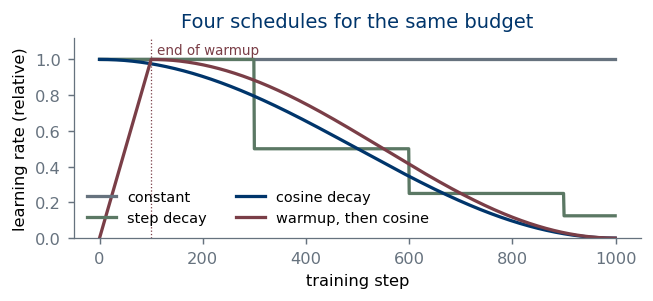

In [15]:
def lr_schedules() -> None:
    """The shapes of the schedules named on the slide."""
    total = 1000
    step = np.arange(total)
    base = 1.0
    warm = 100

    constant = np.full(total, base)
    step_decay = base * 0.5 ** (step // 300)
    cosine = base * 0.5 * (1 + np.cos(np.pi * step / total))
    warm_cosine = np.where(step < warm, base * step / warm,
                           base * 0.5 * (1 + np.cos(np.pi * (step - warm) / (total - warm))))

    fig, ax = plt.subplots(figsize=FULL)
    for values, colour, label in ((constant, MUTED, "constant"),
                                  (step_decay, GREEN, "step decay"),
                                  (cosine, BLUE, "cosine decay"),
                                  (warm_cosine, RED, "warmup, then cosine")):
        ax.plot(step, values, color=colour, label=label)
    ax.axvline(warm, color=RED, lw=.7, ls=":")
    ax.text(warm + 12, 1.03, "end of warmup", fontsize=7.5, color=RED)
    ax.set(xlabel="training step", ylabel="learning rate (relative)",
           ylim=(0, 1.12), title="Four schedules for the same budget")
    ax.legend(loc="lower left", fontsize=8, ncol=2)
    save(fig, OUT / "lr-schedules.pdf", OUT / "lr-schedules.svg")

lr_schedules()

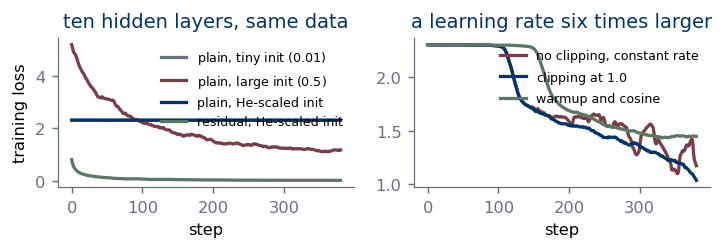

  plain, tiny init ($0.01$)        final smoothed loss 2.302
  plain, large init ($0.5$)        final smoothed loss 1.165
  plain, He-scaled init            final smoothed loss 2.302
  residual, He-scaled init         final smoothed loss 0.010
  no clipping, constant rate       final smoothed loss 1.172
  clipping at $1.0$                final smoothed loss 1.035
  warmup and cosine                final smoothed loss 1.447


In [16]:
def stabilization_comparison() -> None:
    """Train the same network four ways and compare the training curves."""
    import torch
    from torch import nn
    import pandas as pd

    digits = pd.read_csv('SklearnDigits.csv')
    y_all = torch.tensor(digits["target"].to_numpy(), dtype=torch.long)
    X_all = torch.tensor(digits.drop(columns="target").to_numpy(), dtype=torch.float32)
    X_all = (X_all - X_all.mean(0)) / (X_all.std(0) + 1e-6)

    class Deep(nn.Module):
        """Ten hidden layers, optionally residual, with a settable init scale."""

        def __init__(self, residual: bool, gain: float | None, width: int = 64, depth: int = 10):
            super().__init__()
            self.first = nn.Linear(X_all.shape[1], width)
            self.blocks = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
            self.head = nn.Linear(width, 10)
            self.residual = residual
            if gain is not None:
                for layer in [self.first, *self.blocks, self.head]:
                    nn.init.normal_(layer.weight, std=gain)
                    nn.init.zeros_(layer.bias)

        def forward(self, x):
            h = torch.tanh(self.first(x))
            for block in self.blocks:
                out = torch.tanh(block(h))
                h = h + out if self.residual else out
            return self.head(h)

    def run(residual, gain, clip=None, schedule=False, steps=400, lr=0.05, seed=0):
        torch.manual_seed(seed)
        model = Deep(residual, gain)
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
        loss_fn = nn.CrossEntropyLoss()
        history = []
        for t in range(steps):
            if schedule:
                factor = min(1.0, (t + 1) / 40) * 0.5 * (1 + np.cos(np.pi * t / steps))
                for group in optimizer.param_groups:
                    group["lr"] = lr * max(factor, 1e-3)
            index = torch.randint(0, len(X_all), (128,))
            loss = loss_fn(model(X_all[index]), y_all[index])
            optimizer.zero_grad(); loss.backward()
            if clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            history.append(float(loss.detach()))
        return np.convolve(history, np.ones(20) / 20, mode="valid")

    runs = {
        "plain, tiny init ($0.01$)": run(False, 0.01),
        "plain, large init ($0.5$)": run(False, 0.5),
        "plain, He-scaled init": run(False, None),
        "residual, He-scaled init": run(True, None),
    }
    fig, axes = plt.subplots(1, 2, figsize=FULL)
    for (label, curve), colour in zip(runs.items(), [MUTED, RED, BLUE, GREEN]):
        axes[0].plot(curve, color=colour, label=label)
    axes[0].set(xlabel="step", ylabel="training loss", title="ten hidden layers, same data")
    axes[0].legend(fontsize=7)

    variants = {
        "no clipping, constant rate": run(False, None, lr=0.3),
        "clipping at $1.0$": run(False, None, clip=1.0, lr=0.3),
        "warmup and cosine": run(False, None, schedule=True, lr=0.3),
    }
    for (label, curve), colour in zip(variants.items(), [RED, BLUE, GREEN]):
        axes[1].plot(curve, color=colour, label=label)
    axes[1].set(xlabel="step", title="a learning rate six times larger")
    axes[1].legend(fontsize=7)
    fig.tight_layout(w_pad=0.7)
    save(fig, OUT / "stabilization-comparison.pdf", OUT / "stabilization-comparison.svg")
    for name, curve in {**runs, **variants}.items():
        print(f"  {name:32s} final smoothed loss {curve[-1]:.3f}")

stabilization_comparison()

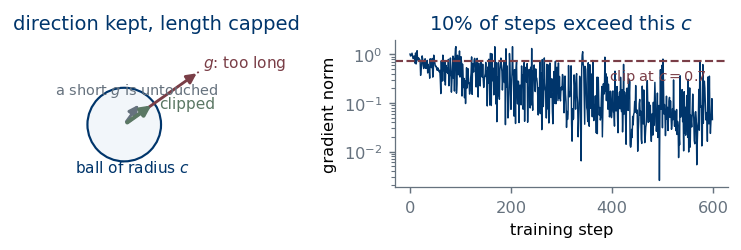

gradient norms: median 0.18, max 1.45, ratio 7.9x


In [17]:
def gradient_clipping() -> None:
    """What clipping does to one vector, and how often it fires in practice."""
    import torch
    from torch import nn
    import pandas as pd

    # --- left: the rule, drawn ---------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=FULL, gridspec_kw={"width_ratios": [1, 1.35]})
    ax = axes[0]
    c = 1.0
    circle = plt.Circle((0, 0), c, facecolor="#F2F6FA", edgecolor=BLUE, lw=1.2, zorder=1)
    ax.add_patch(circle)
    long_g = np.array([2.05, 1.45])
    short_g = np.array([0.45, 0.62])
    clipped = long_g * c / np.linalg.norm(long_g)
    ax.add_patch(FancyArrowPatch((0, 0), tuple(long_g), arrowstyle="-|>", mutation_scale=11,
                                 color=RED, lw=1.6, zorder=3))
    ax.add_patch(FancyArrowPatch((0, 0), tuple(clipped), arrowstyle="-|>", mutation_scale=11,
                                 color=GREEN, lw=2.2, zorder=4))
    ax.add_patch(FancyArrowPatch((0, 0), tuple(short_g), arrowstyle="-|>", mutation_scale=11,
                                 color=MUTED, lw=1.6, zorder=3))
    ax.plot(*zip(clipped, long_g), color=RED, ls=":", lw=1.0, zorder=2)
    ax.text(long_g[0] + 0.08, long_g[1] + 0.10, "$g$: too long", color=RED, fontsize=8.5)
    ax.text(clipped[0] + 0.12, clipped[1] - 0.02, "clipped", color=GREEN, fontsize=8.5,
            va="center")
    ax.text(short_g[0] - 0.10, short_g[1] + 0.22, "a short $g$ is untouched", color=MUTED,
            fontsize=8, ha="center")
    ax.text(-1.35, -1.30, "ball of radius $c$", color=BLUE, fontsize=8.5, ha="left")
    ax.set(xlim=(-1.55, 3.3), ylim=(-1.7, 2.3), aspect="equal", xticks=[], yticks=[],
           title="direction kept, length capped")
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(False)

    # --- right: how often it fires on a real run ---------------------------
    digits = pd.read_csv('SklearnDigits.csv')
    y_all = torch.tensor(digits["target"].to_numpy(), dtype=torch.long)
    X_all = torch.tensor(digits.drop(columns="target").to_numpy(), dtype=torch.float32)
    X_all = (X_all - X_all.mean(0)) / (X_all.std(0) + 1e-6)
    torch.manual_seed(11)
    model = nn.Sequential(nn.Linear(64, 128), nn.Tanh(), nn.Linear(128, 128), nn.Tanh(),
                          nn.Linear(128, 10))
    optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
    loss_fn = nn.CrossEntropyLoss()
    norms = []
    for _ in range(600):
        index = torch.randint(0, len(X_all), (32,))
        loss = loss_fn(model(X_all[index]), y_all[index])
        optimizer.zero_grad(); loss.backward()
        norms.append(float(torch.sqrt(sum((p.grad ** 2).sum() for p in model.parameters()))))
        optimizer.step()
    norms = np.array(norms)
    threshold = float(np.quantile(norms, 0.90))
    ax = axes[1]
    ax.plot(norms, color=BLUE, lw=.8)
    ax.axhline(threshold, color=RED, lw=1.2, ls="--")
    ax.text(len(norms) * 0.98, threshold * 0.72, f"clip at $c={threshold:.1f}$", color=RED,
            fontsize=8, ha="right", va="top")
    ax.set(yscale="log", xlabel="training step", ylabel="gradient norm",
           title=f"{(norms > threshold).mean():.0%} of steps exceed this $c$")
    fig.tight_layout(w_pad=0.7)
    save(fig, OUT / "gradient-clipping.pdf", OUT / "gradient-clipping.svg")
    print(f"gradient norms: median {np.median(norms):.2f}, max {norms.max():.2f}, "
          f"ratio {norms.max()/np.median(norms):.1f}x")

gradient_clipping()

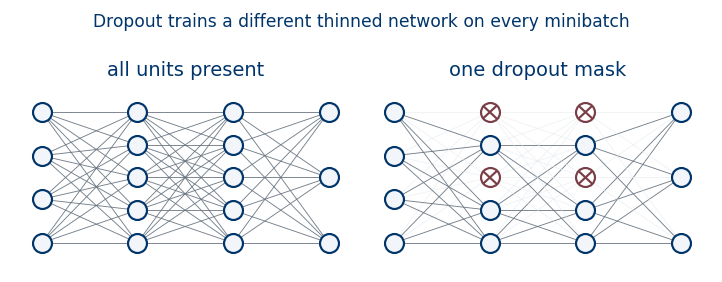

In [18]:
def dropout_figure() -> None:
    """The same small network before and after dropping units."""
    rng = np.random.default_rng(4)
    layers = [4, 5, 5, 3]
    positions = []
    for k, count in enumerate(layers):
        ys = np.linspace(0, 1, count)
        positions.append([(k / (len(layers) - 1), y) for y in ys])

    keep = [[True] * len(layer) for layer in positions]
    for k in (1, 2):
        drop = rng.choice(len(positions[k]), 2, replace=False)
        for j in drop:
            keep[k][j] = False

    fig, axes = plt.subplots(1, 2, figsize=(5.63, 2.15))
    for ax, use_dropout, title in ((axes[0], False, "all units present"),
                                   (axes[1], True, "one dropout mask")):
        for k in range(len(positions) - 1):
            for a, (xa, ya) in enumerate(positions[k]):
                for b, (xb, yb) in enumerate(positions[k + 1]):
                    live = (not use_dropout) or (keep[k][a] and keep[k + 1][b])
                    ax.plot([xa, xb], [ya, yb], color=MUTED if live else "#E6EBF0",
                            lw=.5, alpha=.9 if live else .6, zorder=1)
        for k, layer in enumerate(positions):
            for j, (x, y) in enumerate(layer):
                live = (not use_dropout) or keep[k][j]
                ax.scatter(x, y, s=110, zorder=3,
                           facecolor="#F2F6FA" if live else "white",
                           edgecolor=BLUE if live else RED,
                           linewidth=1.2)
                if not live:
                    ax.plot([x - .022, x + .022], [y - .045, y + .045], color=RED, lw=1.2, zorder=4)
                    ax.plot([x - .022, x + .022], [y + .045, y - .045], color=RED, lw=1.2, zorder=4)
        ax.set(xlim=(-0.1, 1.1), ylim=(-0.2, 1.2), xticks=[], yticks=[], title=title)
        ax.axis("off")
    fig.suptitle("Dropout trains a different thinned network on every minibatch",
                 fontsize=9.5, color=BLUE)
    fig.tight_layout(w_pad=0.5)
    save(fig, OUT / "dropout-mlp.pdf", OUT / "dropout-mlp.svg")

dropout_figure()